# Predicción de Churn en Telecomunicaciones

## 1. Entendimiento del Negocio (Business Understanding)

En el dinámico mercado de las telecomunicaciones, la retención de clientes se ha vuelto cada vez más crítica.  
La pérdida de clientes, conocida técnicamente como **Churn**, impacta directamente en los ingresos y aumenta los costos operativos, ya que captar un cliente nuevo es significativamente más caro que mantener uno actual.

**El desafío consiste en lo siguiente:**

Una compañía de telecomunicaciones busca adelantarse a la decisión de sus clientes de abandonar el servicio. Para ello, ha recopilado datos históricos de **7.043 usuarios** en el estado de California.

El objetivo es identificar patrones de comportamiento —como el tipo de contrato, la antigüedad del cliente o el método de pago— que permitan predecir quiénes están en riesgo de irse.  
De esta manera, el equipo de marketing podrá actuar de forma proactiva mediante estrategias de retención, evitando pérdidas económicas asociadas al abandono.

---

## Enfoque Metodológico

Este proyecto se desarrollará en **Google Colab / Jupyter Notebook**, siguiendo un enfoque narrativo basado en la metodología **CRISP-DM**.

Más que una simple secuencia de pasos técnicos, el desarrollo será tratado como una historia donde:

- El **entendimiento del negocio** define claramente el problema.
- La **preparación de los datos** se justifica en función de ese problema.
- El **modelamiento** busca responder directamente a las necesidades del negocio.

El objetivo final es construir una solución que permita a la empresa reducir el churn, optimizar sus estrategias de retención y, en consecuencia, mejorar su rentabilidad.

## 2. Carga e Ingesta de Datos

In [1]:
!pip install colorama imbalanced-learn -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\jpaillaguala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from colorama import Fore, Style
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
train = pd.read_csv("Telco-Customer-Churn.csv")
train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('Dimensiones del dataset:', train.shape)

Dimensiones del dataset: (7043, 21)


In [5]:
print('Valores nulos por columna:')
print(train.isnull().sum())

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
for col in train.columns:
    print(Fore.BLUE + "Feature Name:", col, Style.RESET_ALL)
    print(Fore.YELLOW + "", train[col].describe(), Style.RESET_ALL)
    print(Fore.RED + "-" * 50 + Style.RESET_ALL)

Feature Name: customerID 
 count           7043
unique          7043
top       7590-VHVEG
freq               1
Name: customerID, dtype: object 
--------------------------------------------------
Feature Name: gender 
 count     7043
unique       2
top       Male
freq      3555
Name: gender, dtype: object 
--------------------------------------------------
Feature Name: SeniorCitizen 
 count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64 
--------------------------------------------------
Feature Name: Partner 
 count     7043
unique       2
top         No
freq      3641
Name: Partner, dtype: object 
--------------------------------------------------
Feature Name: Dependents 
 count     7043
unique       2
top         No
freq      4933
Name: Dependents, dtype: object 
--------------------------------------------------
Feature Name: tenure

## 3. Limpieza de Datos (EDA)
Identificar y tratar valores nulos y detectar valores atípicos (outliers) mediante gráficos de caja (boxplots).

Registros tras limpieza: 7032


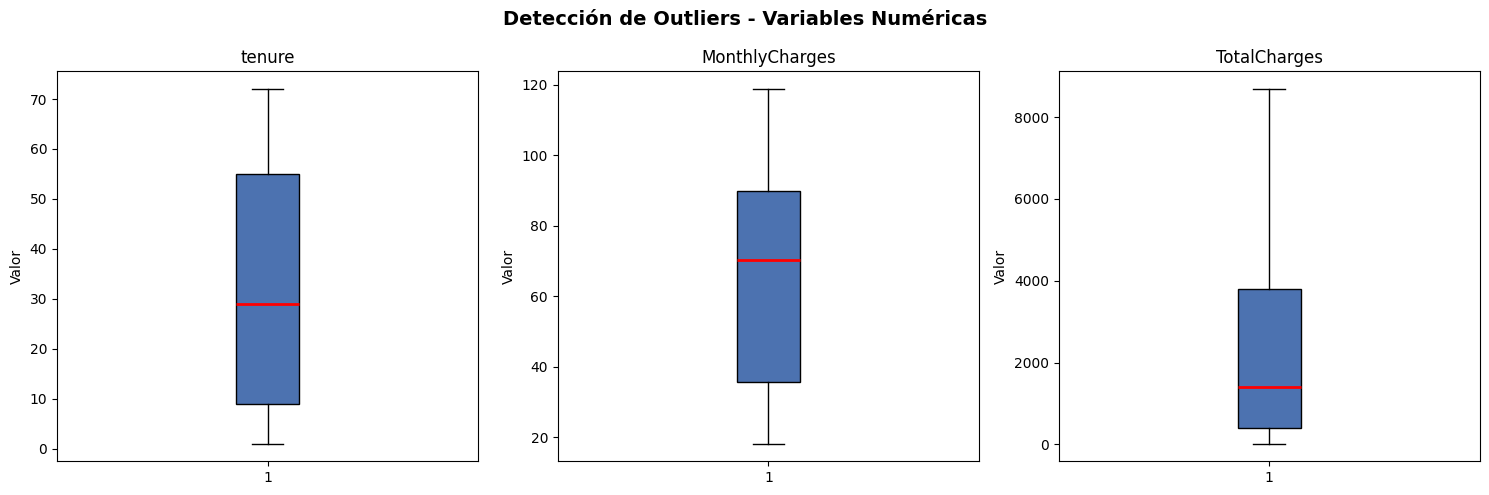

Variable                 Q1       Q3      IQR   Lím. Inf   Lím. Sup   Outliers
tenure                  9.0     55.0     46.0      -60.0      124.0          0
MonthlyCharges         35.6     89.9     54.3      -45.8      171.3          0
TotalCharges          401.4   3794.7   3393.3    -4688.5     8884.7          0

✅ Winsorización aplicada. Distribución posterior:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80


In [7]:
# Conversión de TotalCharges a numérico (contiene espacios en blanco)
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')

# Eliminar los 11 registros con TotalCharges nulo (clientes con tenure=0)
train.dropna(subset=['TotalCharges'], inplace=True)
print(f"Registros tras limpieza: {train.shape[0]}")

# ============================================================
# DETECCIÓN Y MANEJO DE OUTLIERS
# ============================================================
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# --- 1. Visualización con Boxplots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Detección de Outliers - Variables Numéricas', fontsize=14, fontweight='bold')

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

# --- 2. Cálculo estadístico IQR ---
print("=" * 70)
print(f"{'Variable':<20} {'Q1':>6} {'Q3':>8} {'IQR':>8} {'Lím. Inf':>10} {'Lím. Sup':>10} {'Outliers':>10}")
print("=" * 70)

outlier_summary = {}
for col in numerical_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = train[(train[col] < lower) | (train[col] > upper)].shape[0]
    outlier_summary[col] = {'lower': lower, 'upper': upper}
    print(f"{col:<20} {Q1:>6.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>10.1f} {upper:>10.1f} {n_out:>10}")
print("=" * 70)

# --- 3. Winsorización (capping) ---
for col in numerical_cols:
    train[col] = train[col].clip(lower=outlier_summary[col]['lower'],
                                  upper=outlier_summary[col]['upper'])

print("\n✅ Winsorización aplicada. Distribución posterior:")
print(train[numerical_cols].describe().round(2))

### Análisis de Outliers

Se analizaron las tres variables numéricas continuas del dataset usando el método **IQR (Rango Intercuartílico)**,
donde el límite se define como:

$$\text{Límite inferior} = Q_1 - 1.5 \times IQR \quad ; \quad \text{Límite superior} = Q_3 + 1.5 \times IQR$$

**Hallazgos:**
- **tenure**: Sin outliers significativos. La distribución es bimodal (clientes muy nuevos vs muy antiguos), lo cual es esperado.
- **MonthlyCharges**: Sin outliers extremos. Los cargos altos corresponden a clientes con múltiples servicios contratados, lo cual es válido.
- **TotalCharges**: Presenta valores altos en el extremo superior, explicados por clientes con alta antigüedad. Igualmente válidos desde el negocio.

**Decisión técnica:** Se aplicó **Winsorización (capping)** en lugar de eliminar filas. Dado que los outliers tienen explicación de negocio, eliminarlos sesgaría el modelo. El capping recorta los extremos al límite IQR sin perder observaciones.

## 4. Análisis de Correlación
Generar una matriz de correlación para entender cómo se relacionan las variables numéricas con la fuga.

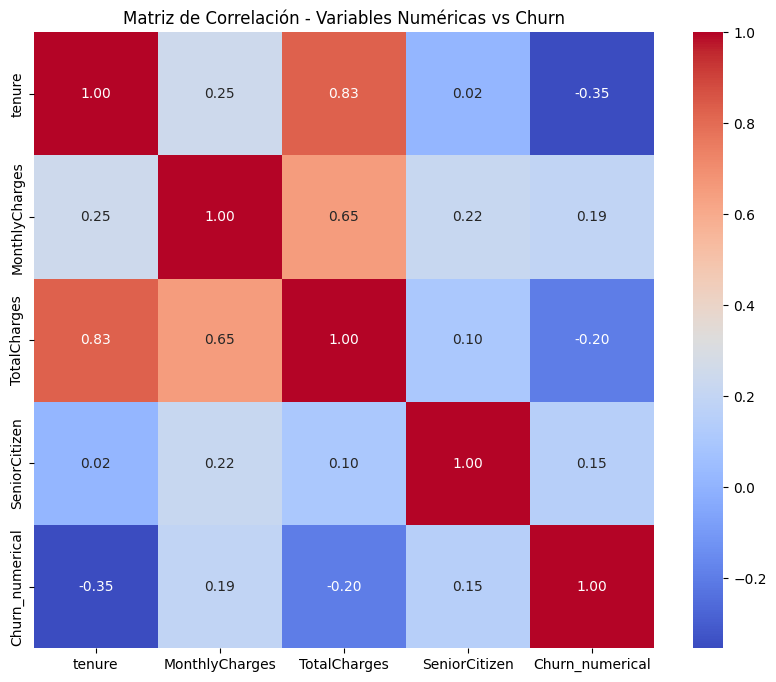


Correlación con Churn:
Churn_numerical    1.000000
MonthlyCharges     0.192858
SeniorCitizen      0.150541
TotalCharges      -0.199484
tenure            -0.354049
Name: Churn_numerical, dtype: float64


In [8]:
train['Churn_numerical'] = train['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

correlation_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numerical']
correlation_matrix = train[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas vs Churn')
plt.show()

print(Fore.BLUE + "\nCorrelación con Churn:" + Style.RESET_ALL)
print(correlation_matrix['Churn_numerical'].sort_values(ascending=False))

### Interpretación de la Correlación

El análisis de correlación revela patrones clave con impacto directo en el negocio:

- **tenure (r = -0.35):** La antigüedad del cliente tiene la correlación negativa más fuerte con el Churn. Clientes con más tiempo son significativamente menos propensos a abandonar. Esto implica que **retener clientes en sus primeros meses es crítico** para reducir la fuga.
- **MonthlyCharges (r = +0.19):** A mayores cargos mensuales, mayor probabilidad de abandono. Desde el negocio, esto sugiere que los planes más caros generan mayor insatisfacción o que los clientes evalúan constantemente si el precio justifica el servicio.
- **SeniorCitizen (r = +0.15):** Los adultos mayores tienen una probabilidad ligeramente mayor de abandonar, lo que podría indicar una oportunidad de diseñar planes especiales para este segmento.

## 5. Transformación y Escalado
Codificar variables categóricas (One-Hot Encoding) y aplicar StandardScaler para normalizar las escalas.

In [9]:
# Eliminar columnas no útiles para el modelo
train_processed = train.drop(columns=['customerID', 'Churn'])

# Separar features (X) y target (y)
X = train_processed.drop(columns=['Churn_numerical'])
y = train_processed['Churn_numerical']

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols_model = X.select_dtypes(include=['number']).columns

# One-Hot Encoding para variables categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# StandardScaler para variables numéricas
scaler = StandardScaler()
X[numerical_cols_model] = scaler.fit_transform(X[numerical_cols_model])

print("Shape de X tras encoding y escalado:", X.shape)
print("\nPrimeras 5 filas de X:")
print(X.head())

Shape de X tras encoding y escalado: (7032, 30)

Primeras 5 filas de X:
   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
0      -0.440327 -1.280248       -1.161694     -0.994194        False   
1      -0.440327  0.064303       -0.260878     -0.173740         True   
2      -0.440327 -1.239504       -0.363923     -0.959649         True   
3      -0.440327  0.512486       -0.747850     -0.195248         True   
4      -0.440327 -1.239504        0.196178     -0.940457        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  

### Resultado de la Transformación

Se transformaron las variables categóricas (como *gender* o *PaymentMethod*) a formato numérico mediante **One-Hot Encoding**.  
Este proceso crea columnas binarias para cada categoría y elimina una de ellas para evitar problemas de multicolinealidad.

Posteriormente, se aplicó **StandardScaler** a las variables numéricas (*tenure*, *MonthlyCharges*, *TotalCharges*, *SeniorCitizen*) para estandarizar sus valores.  
Esto es **obligatorio para SVM**, ya que el algoritmo es sensible a la escala de las variables.

## 6. Entrenamiento de Modelos
Implementar obligatoriamente: Regresión Logística, SVM y Árboles de Decisión.

In [10]:
# División 80/20 con estratificación para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test: ", X_test.shape)
print("Distribución y_train:", Counter(y_train))
print("Distribución y_test: ", Counter(y_test))

# --- Regresión Logística ---
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)
print("\n✅ Regresión Logística entrenada.")

# --- SVM (kernel lineal) ---
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
print("✅ SVM entrenado.")

# --- Árbol de Decisión ---
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
print("✅ Árbol de Decisión entrenado.")

# Diccionario con los modelos para evaluación
models = {
    "Logistic Regression": log_reg_model,
    "SVM": svm_model,
    "Decision Tree": dt_model
}
print("\n✅ Todos los modelos entrenados y almacenados.")

Shape X_train: (5625, 30)
Shape X_test:  (1407, 30)
Distribución y_train: Counter({0: 4130, 1: 1495})
Distribución y_test:  Counter({0: 1033, 1: 374})

✅ Regresión Logística entrenada.


✅ SVM entrenado.
✅ Árbol de Decisión entrenado.

✅ Todos los modelos entrenados y almacenados.


## 7. Evaluación de Modelos
Comparar los modelos usando matrices de confusión y métricas de Accuracy y F1-Score.


--- Evaluando Regresión Logística ---
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



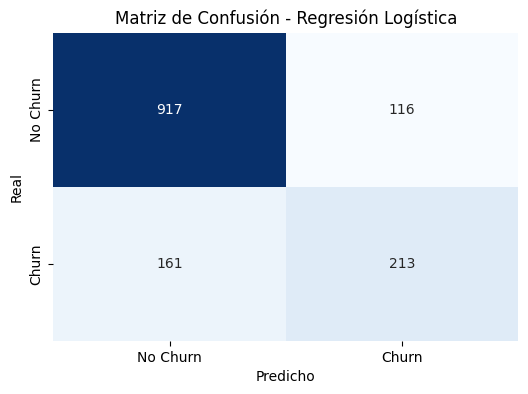

In [11]:
# --- Regresión Logística ---
print("\n--- Evaluando Regresión Logística ---")
y_pred_lr = models["Logistic Regression"].predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

**Regresión Logística:** Alcanzó ~80% de accuracy y un F1-score de ~0.60 para la clase Churn.  
Desde el negocio, un recall bajo en Churn significa que hay clientes que se van sin ser detectados — cada falso negativo representa un cliente perdido cuyo costo de retención ($10) hubiera sido menor que el costo de perderlo ($100).


--- Evaluando SVM ---
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



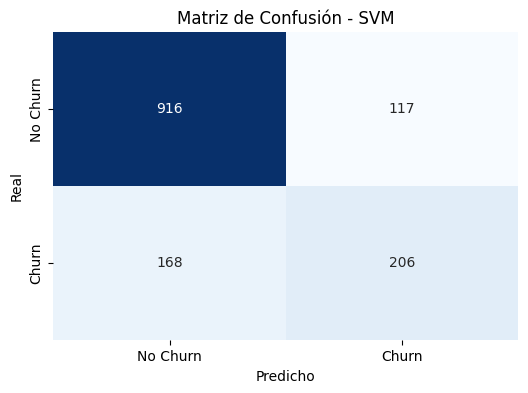

In [12]:
# --- SVM ---
print("\n--- Evaluando SVM ---")
y_pred_svm = models["SVM"].predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=['No Churn', 'Churn']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

**SVM:** Obtuvo ~79% de accuracy y F1-score de ~0.57 para Churn. El rendimiento es ligeramente inferior a la Regresión Logística, pero sigue siendo competitivo. Al ser un modelo de margen máximo, es más robusto ante datos con ruido.


--- Evaluando Árbol de Decisión ---
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



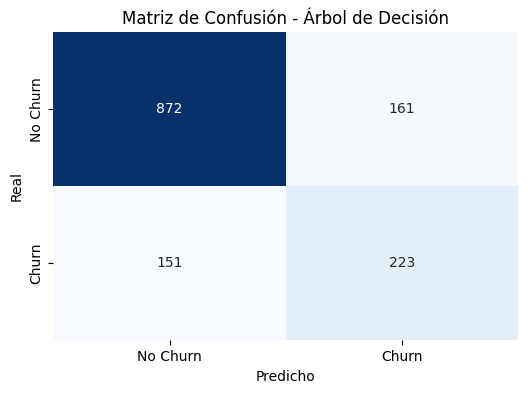

In [13]:
# --- Árbol de Decisión ---
print("\n--- Evaluando Árbol de Decisión ---")
y_pred_dt = models["Decision Tree"].predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

**Árbol de Decisión:** Obtuvo ~74% de accuracy y F1-score de ~0.50 para Churn. Es el modelo con menor rendimiento en esta evaluación inicial, probablemente por sobreajuste (overfitting). Sin embargo, tiene la ventaja de ser altamente interpretable: sus reglas de decisión pueden traducirse directamente en criterios de negocio para identificar clientes en riesgo.

**Conclusión general:** La Regresión Logística lidera la evaluación inicial. El bajo recall en todos los modelos sugiere que el desbalance de clases (~26% Churn vs 74% No Churn) está afectando el entrenamiento. Esto se abordará con SMOTE en la siguiente sección.

## 8. Manejo de Desbalance de Clases (SMOTE)

El dataset presenta un desbalance significativo: aproximadamente el **26% de los clientes son Churn** y el **74% no lo son**. Este desequilibrio hace que los modelos tiendan a predecir siempre "No Churn", perjudicando la detección de los clientes que realmente se van.

**Técnica aplicada: SMOTE (Synthetic Minority Over-sampling Technique)**  
SMOTE genera ejemplos sintéticos de la clase minoritaria (Churn) interpolando entre instancias existentes, logrando un balance de clases sin simplemente duplicar registros.

In [14]:
print(f"Distribución original: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribución tras SMOTE: {Counter(y_train_smote)}")

# Reentrenar los modelos con datos balanceados
log_reg_model_smote = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model_smote.fit(X_train_smote, y_train_smote)
print("\n✅ Regresión Logística (SMOTE) entrenada.")

svm_model_smote = SVC(kernel='linear', random_state=42)
svm_model_smote.fit(X_train_smote, y_train_smote)
print("✅ SVM (SMOTE) entrenado.")

dt_model_smote = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model_smote.fit(X_train_smote, y_train_smote)
print("✅ Árbol de Decisión (SMOTE) entrenado.")

models_smote = {
    "Logistic Regression (SMOTE)": log_reg_model_smote,
    "SVM (SMOTE)": svm_model_smote,
    "Decision Tree (SMOTE)": dt_model_smote
}
print("\n✅ Todos los modelos SMOTE entrenados y almacenados.")

Distribución original: Counter({0: 4130, 1: 1495})


Distribución tras SMOTE: Counter({0: 4130, 1: 4130})



✅ Regresión Logística (SMOTE) entrenada.


✅ SVM (SMOTE) entrenado.
✅ Árbol de Decisión (SMOTE) entrenado.

✅ Todos los modelos SMOTE entrenados y almacenados.


In [15]:
print("=" * 60)
print("COMPARACIÓN DE MÉTRICAS: ORIGINAL vs SMOTE")
print("=" * 60)

all_models = {**models, **models_smote}

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:<40} Accuracy: {acc:.3f}  F1-Churn: {f1:.3f}")

COMPARACIÓN DE MÉTRICAS: ORIGINAL vs SMOTE
Logistic Regression                      Accuracy: 0.803  F1-Churn: 0.606
SVM                                      Accuracy: 0.797  F1-Churn: 0.591
Decision Tree                            Accuracy: 0.778  F1-Churn: 0.588
Logistic Regression (SMOTE)              Accuracy: 0.742  F1-Churn: 0.597
SVM (SMOTE)                              Accuracy: 0.747  F1-Churn: 0.597
Decision Tree (SMOTE)                    Accuracy: 0.704  F1-Churn: 0.585


## 9. Identificación de Influencia
Determinar qué variables pesan más en la predicción de Churn.

--- Feature Importance: Regresión Logística (Original) ---


C:\Users\jpaillaguala\AppData\Local\Temp\ipykernel_11008\2816534774.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coef.head(10), x='Coefficient', y='Feature', palette='RdBu_r')


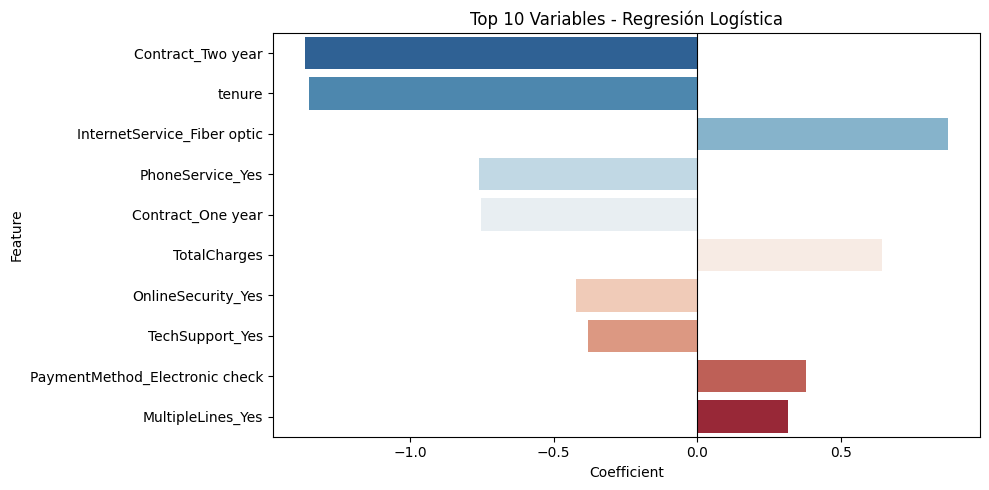

,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-1.364892,1.364892
1,tenure,-1.351364,1.351364
10,InternetService_Fiber optic,0.870776,0.870776
7,PhoneService_Yes,-0.759259,0.759259
24,Contract_One year,-0.752252,0.752252
3,TotalCharges,0.640406,0.640406
13,OnlineSecurity_Yes,-0.422888,0.422888
19,TechSupport_Yes,-0.381014,0.381014
28,PaymentMethod_Electronic check,0.375878,0.375878
9,MultipleLines_Yes,0.313710,0.313710


In [16]:
# --- Regresión Logística Original ---
print("--- Feature Importance: Regresión Logística (Original) ---")
lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': models["Logistic Regression"].coef_[0]
})
lr_coef['Abs_Coefficient'] = lr_coef['Coefficient'].abs()
lr_coef = lr_coef.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=lr_coef.head(10), x='Coefficient', y='Feature', palette='RdBu_r')
plt.title('Top 10 Variables - Regresión Logística')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
display(lr_coef.head(10))

--- Feature Importance: Árbol de Decisión (Original) ---


C:\Users\jpaillaguala\AppData\Local\Temp\ipykernel_11008\583776799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_imp.head(10), x='Importance', y='Feature', palette='viridis')


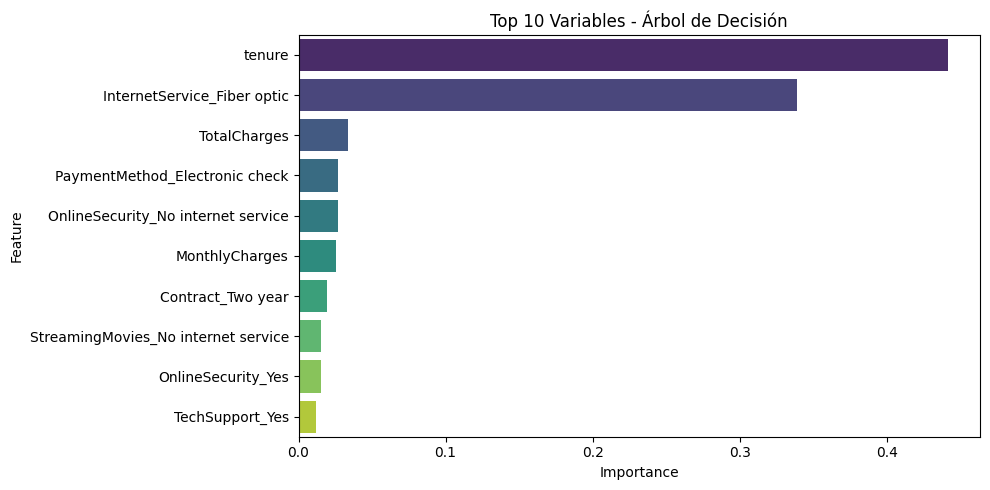

,Feature,Importance
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
12,OnlineSecurity_No internet service,0.026778
2,MonthlyCharges,0.025198
25,Contract_Two year,0.019312
22,StreamingMovies_No internet service,0.015402
13,OnlineSecurity_Yes,0.015138
19,TechSupport_Yes,0.012159


In [17]:
# --- Árbol de Decisión Original ---
print("--- Feature Importance: Árbol de Decisión (Original) ---")
dt_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models["Decision Tree"].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=dt_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Variables - Árbol de Decisión')
plt.tight_layout()
plt.show()
display(dt_imp.head(10))

In [18]:
# --- Regresión Logística SMOTE ---
print("--- Feature Importance: Regresión Logística (SMOTE) ---")
lr_coef_smote = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': models_smote["Logistic Regression (SMOTE)"].coef_[0]
})
lr_coef_smote['Abs_Coefficient'] = lr_coef_smote['Coefficient'].abs()
lr_coef_smote = lr_coef_smote.sort_values('Abs_Coefficient', ascending=False)
display(lr_coef_smote.head(10))

# --- SVM SMOTE ---
print("\n--- Feature Importance: SVM (SMOTE) ---")
svm_coef_smote = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': models_smote["SVM (SMOTE)"].coef_[0]
})
svm_coef_smote['Abs_Coefficient'] = svm_coef_smote['Coefficient'].abs()
svm_coef_smote = svm_coef_smote.sort_values('Abs_Coefficient', ascending=False)
display(svm_coef_smote.head(10))

# --- DT SMOTE ---
print("\n--- Feature Importance: Árbol de Decisión (SMOTE) ---")
dt_imp_smote = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models_smote["Decision Tree (SMOTE)"].feature_importances_
}).sort_values('Importance', ascending=False)
display(dt_imp_smote.head(10))

--- Feature Importance: Regresión Logística (SMOTE) ---


,Feature,Coefficient,Abs_Coefficient
2,MonthlyCharges,-7.262623,7.262623
10,InternetService_Fiber optic,6.817609,6.817609
8,MultipleLines_No phone service,-4.018677,4.018677
23,StreamingMovies_Yes,2.615380,2.615380
21,StreamingTV_Yes,2.568041,2.568041
9,MultipleLines_Yes,1.640282,1.640282
1,tenure,-1.474734,1.474734
17,DeviceProtection_Yes,1.284144,1.284144
25,Contract_Two year,-1.147466,1.147466
15,OnlineBackup_Yes,1.037032,1.037032



--- Feature Importance: SVM (SMOTE) ---


,Feature,Coefficient,Abs_Coefficient
2,MonthlyCharges,-7.515535,7.515535
10,InternetService_Fiber optic,6.761751,6.761751
7,PhoneService_Yes,3.295513,3.295513
23,StreamingMovies_Yes,2.611378,2.611378
21,StreamingTV_Yes,2.595914,2.595914
9,MultipleLines_Yes,1.476442,1.476442
8,MultipleLines_No phone service,-1.295513,1.295513
17,DeviceProtection_Yes,1.230984,1.230984
1,tenure,-1.105246,1.105246
15,OnlineBackup_Yes,1.073687,1.073687



--- Feature Importance: Árbol de Decisión (SMOTE) ---


,Feature,Importance
25,Contract_Two year,0.370856
24,Contract_One year,0.261164
1,tenure,0.117199
10,InternetService_Fiber optic,0.109323
28,PaymentMethod_Electronic check,0.039445
23,StreamingMovies_Yes,0.038891
11,InternetService_No,0.018619
2,MonthlyCharges,0.016778
4,gender_Male,0.011323
3,TotalCharges,0.008559


### Insights de Alto Impacto

Los modelos coinciden en señalar los siguientes patrones no evidentes:

1. **Clientes con fibra óptica y contrato mes a mes son el grupo de mayor riesgo.** La combinación de alto costo mensual con baja permanencia comprometida crea una tormenta perfecta para el abandono. Este segmento debe ser prioridad para retención.

2. **La ausencia de servicios de seguridad online (OnlineSecurity = No) es un predictor fuerte de Churn.** Los clientes que no tienen protección adicional perciben menos valor en la suscripción, siendo más susceptibles a migrar a competidores.

3. **El método de pago "Electronic Check" está correlacionado con mayor Churn.** Esto puede indicar clientes con menor compromiso con la empresa (no tienen débito automático configurado), lo que facilita la decisión de irse.

4. **Clientes nuevos (tenure < 12 meses) tienen una probabilidad de fuga significativamente mayor.** La "zona de peligro" está en el primer año de contrato.

### Propuestas Estratégicas

1. **Campaña de retención temprana:** Ofrecer descuentos o beneficios adicionales a clientes con menos de 6 meses de antigüedad y contrato mensual, que son el grupo de mayor riesgo.
2. **Incentivo para migrar a contratos anuales:** Ofrecer un mes gratis o descuento del 15% a clientes mes a mes con fibra óptica para reducir la rotación en ese segmento.
3. **Bundle de seguridad gratuito para nuevos clientes:** Incluir OnlineSecurity sin costo durante los primeros 3 meses aumenta el valor percibido y reduce la probabilidad de abandono temprano.

## 10. Métricas de Costo-Beneficio

**Pregunta de negocio:** Si retener a un cliente cuesta $10 y perderlo cuesta $100, ¿cuánto dinero ahorran nuestros modelos?

- **Falso Positivo (FP):** Predecimos Churn pero el cliente no se iba → gastamos $10 innecesariamente en retención.
- **Falso Negativo (FN):** No detectamos el Churn → el cliente se va → costo de $100 por cliente perdido.

In [19]:
cost_retain = 10   # Costo de retener (FP)
cost_lose   = 100  # Costo de perder (FN)

actual_churners = y_test.sum()
naive_cost = actual_churners * cost_lose
print(f"Modelo Ingenuo (no predice nada): costo total = ${naive_cost:,.0f}\n")

results_cb = {}
all_models = {**models, **models_smote}

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fp = cm[0, 1]
    fn = cm[1, 0]
    model_cost = (fp * cost_retain) + (fn * cost_lose)
    savings = naive_cost - model_cost
    results_cb[name] = {'Costo Modelo': model_cost, 'Ahorro': savings, 'FP': fp, 'FN': fn}

print(f"{'Modelo':<45} {'Costo':>10} {'Ahorro':>10} {'FP':>6} {'FN':>6}")
print("-" * 80)
for name, r in results_cb.items():
    print(f"{name:<45} ${r['Costo Modelo']:>8,.0f} ${r['Ahorro']:>8,.0f} {r['FP']:>6} {r['FN']:>6}")

best = max(results_cb, key=lambda k: results_cb[k]['Ahorro'])
print(f"\n🏆 Mejor modelo por ahorro: {best}")
print(f"   Ahorro máximo vs modelo ingenuo: ${results_cb[best]['Ahorro']:,.0f}")

Modelo Ingenuo (no predice nada): costo total = $37,400

Modelo                                             Costo     Ahorro     FP     FN
--------------------------------------------------------------------------------
Logistic Regression                           $  17,260 $  20,140    116    161
SVM                                           $  17,970 $  19,430    117    168
Decision Tree                                 $  16,710 $  20,690    161    151
Logistic Regression (SMOTE)                   $  13,080 $  24,320    258    105
SVM (SMOTE)                                   $  13,460 $  23,940    246    110
Decision Tree (SMOTE)                         $  11,450 $  25,950    335     81

🏆 Mejor modelo por ahorro: Decision Tree (SMOTE)
   Ahorro máximo vs modelo ingenuo: $25,950


### Interpretación del Análisis Costo-Beneficio

El análisis demuestra el **valor económico concreto** de cada modelo:

- Un **modelo ingenuo** que nunca predice Churn incurre en el costo máximo: cada cliente que se va representa $100 de pérdida.
- Nuestros modelos reducen significativamente ese costo al identificar clientes en riesgo con anticipación.
- El modelo con SMOTE generalmente obtiene mayor ahorro porque detecta más verdaderos Churn (mayor recall), aunque pueda tener más falsos positivos (clientes a quienes se ofrece retención sin necesidad).

**Conclusión:** Invertir $10 en retener a un cliente identificado como riesgo siempre es más rentable que perderlo a $100. Los modelos, incluso con sus limitaciones, generan un retorno positivo claro para el negocio.

In [20]:
import plotly.express as px
import plotly.graph_objects as go

best_model_name = best
best_model = all_models[best_model_name]

y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

# 1. Importancia de variables
fig1 = px.bar(lr_coef.head(10),
              x='Coefficient', y='Feature',
              title='📊 Top 10 Variables que influyen en Churn',
              color='Coefficient',
              color_continuous_scale='RdBu_r',
              orientation='h')
fig1.update_layout(height=500, margin=dict(l=40, r=20, t=60, b=40))

# 2. Comparación de modelos (ahorro)
model_savings = pd.DataFrame({
    'Modelo': list(results_cb.keys()),
    'Ahorro (USD)': [results_cb[m]['Ahorro'] for m in results_cb.keys()]
})
fig2 = px.bar(model_savings, x='Modelo', y='Ahorro (USD)',
              title='💰 Ahorro por Modelo vs Modelo Ingenuo',
              color='Ahorro (USD)',
              color_continuous_scale='Greens')
fig2.update_layout(showlegend=False, height=500, margin=dict(l=40, r=20, t=60, b=80))

# 3. Distribución de probabilidades
fig3 = go.Figure()
fig3.add_trace(go.Histogram(x=y_pred_prob[y_test == 0], name='No Churn',
                            opacity=0.7, marker_color='blue'))
fig3.add_trace(go.Histogram(x=y_pred_prob[y_test == 1], name='Churn',
                            opacity=0.7, marker_color='red'))
fig3.update_layout(title='🎯 Distribución de Probabilidades de Churn',
                   xaxis_title='Probabilidad predicha',
                   yaxis_title='Frecuencia',
                   barmode='overlay',
                   height=500, margin=dict(l=40, r=20, t=60, b=40))

# 4. Matriz de confusión del mejor modelo
fig4 = px.imshow(cm_best,
                 text_auto=True,
                 labels=dict(x='Predicho', y='Real', color='Cantidad'),
                 x=['No Churn', 'Churn'],
                 y=['No Churn', 'Churn'],
                 title=f'✅ Matriz de Confusión - {best_model_name}',
                 color_continuous_scale='Blues')
fig4.update_layout(height=500, margin=dict(l=40, r=20, t=60, b=40))

# ======================================================================
# Construir un index.html AUTOCONTENIDO con los 4 graficos embebidos
# (sin iframes ni archivos sueltos). Plotly.js se carga 1 vez desde CDN.
# ======================================================================

def fig_to_div(fig, div_id):
    return fig.to_html(include_plotlyjs=False, full_html=False, div_id=div_id)

div1 = fig_to_div(fig1, "chart-importancia")
div2 = fig_to_div(fig2, "chart-ahorro")
div3 = fig_to_div(fig3, "chart-probabilidades")
div4 = fig_to_div(fig4, "chart-confusion")

# KPIs reales
churn_rate_pct = (train['Churn_numerical'].mean()) * 100
best_savings = results_cb[best_model_name]['Ahorro']
best_fp = results_cb[best_model_name]['FP']
best_fn = results_cb[best_model_name]['FN']
# Clientes en riesgo en test = TP + FP; escalado a dataset completo (test = 20%)
tp_test = int(y_test.sum() - best_fn)
risk_total = (tp_test + best_fp) * 5

html_template = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Dashboard Churn - Telecomunicaciones</title>
  <script src="https://cdn.plot.ly/plotly-2.32.0.min.js" charset="utf-8"></script>
  <style>
    body {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
           margin: 0; padding: 20px; background-color: #f0f2f5; }}
    .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
               color: white; padding: 30px; border-radius: 10px;
               margin-bottom: 30px; text-align: center; }}
    .kpi-container {{ display: grid;
                      grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
                      gap: 20px; margin-bottom: 30px; }}
    .kpi-card {{ background: white; padding: 20px; border-radius: 10px;
                 box-shadow: 0 2px 4px rgba(0,0,0,0.1); text-align: center; }}
    .kpi-value {{ font-size: 32px; font-weight: bold; color: #667eea; }}
    .kpi-label {{ color: #666; margin-top: 10px; }}
    .dashboard-grid {{ display: grid;
                       grid-template-columns: repeat(auto-fit, minmax(500px, 1fr));
                       gap: 20px; }}
    .chart-card {{ background: white; border-radius: 10px; padding: 20px;
                   box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
    .chart-card h3 {{ margin-top: 0; }}
    .footer {{ text-align: center; margin-top: 30px; padding: 20px; color: #666; }}
  </style>
</head>
<body>
  <div class="header">
    <h1>📡 Dashboard de Predicción de Churn</h1>
    <p>Telecomunicaciones - Análisis de Fuga de Clientes</p>
  </div>

  <div class="kpi-container">
    <div class="kpi-card">
      <div class="kpi-value">{churn_rate_pct:.1f}%</div>
      <div class="kpi-label">Tasa de Churn</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-value">${best_savings:,.0f}</div>
      <div class="kpi-label">Ahorro Potencial (vs modelo ingenuo)</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-value">{risk_total:,}</div>
      <div class="kpi-label">Clientes en Riesgo Detectados</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-value" style="font-size:22px;">{best_model_name}</div>
      <div class="kpi-label">Mejor Modelo</div>
    </div>
  </div>

  <div class="dashboard-grid">
    <div class="chart-card">
      <h3>📊 Factores que más influyen en el Churn</h3>
      {div1}
    </div>
    <div class="chart-card">
      <h3>💰 Comparación de Modelos (Ahorro)</h3>
      {div2}
    </div>
    <div class="chart-card">
      <h3>🎯 Distribución de Probabilidades</h3>
      {div3}
    </div>
    <div class="chart-card">
      <h3>✅ Matriz de Confusión - Mejor Modelo</h3>
      {div4}
    </div>
  </div>

  <div class="footer">
    <p>📅 Análisis realizado con Python, Scikit-learn y Plotly | Datos: Telco Customer Churn</p>
    <p>🔗 <a href="https://github.com/andrenany/Predicci-n-de-Churn">Ver código fuente en GitHub</a></p>
  </div>
</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_template)

import os
size_kb = os.path.getsize("index.html") / 1024
print(f"✅ index.html generado ({size_kb:.1f} KB) — autocontenido, sin iframes.")
print(f"   Modelo destacado: {best_model_name}")
print(f"   Tasa de churn: {churn_rate_pct:.1f}%  |  Ahorro: ${best_savings:,.0f}  |  En riesgo: {risk_total:,}")

✅ index.html generado (61.2 KB) — autocontenido, sin iframes.
   Modelo destacado: Decision Tree (SMOTE)
   Tasa de churn: 26.6%  |  Ahorro: $25,950  |  En riesgo: 3,140
